<a href="https://colab.research.google.com/github/nourmsdk/PFE/blob/main/Volume_reclamamtions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import files
uploaded = files.upload()

Saving FactReclamations.csv to FactReclamations (5).csv


In [14]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [15]:

CSV_PATH = "FactReclamations.csv"
DATE_COL = "Date Creation"
HORIZON_SEMAINES = 12        # ~3 mois
TEST_SIZE_SEMAINES = 8
REGIME_START = "2025-01-01"  # début du régime actuel
N_LAGS = 4                   # nb de semaines passées utilisées comme features

In [16]:

# 1. Chargement et agrégation hebdomadaire
# ---------------------------------------------------------------------------

df = pd.read_csv(CSV_PATH, sep=";", encoding="utf-8-sig")
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL])

weekly = df.set_index(DATE_COL).resample("W-MON").size()
weekly.name = "nb_reclamations"

last_data_date = df[DATE_COL].max()
if last_data_date < weekly.index[-1]:
    print(f"Semaine en cours exclue : données disponibles seulement jusqu'au {last_data_date.date()}.")
    weekly = weekly.iloc[:-1]

serie = weekly[weekly.index >= REGIME_START]
print(f"\nSérie retenue depuis {REGIME_START} ({len(serie)} semaines)")
print(serie.tail(15))


Semaine en cours exclue : données disponibles seulement jusqu'au 2026-07-08.

Série retenue depuis 2025-01-01 (79 semaines)
Date Creation
2026-03-30    28
2026-04-06     9
2026-04-13    20
2026-04-20    16
2026-04-27    14
2026-05-04    12
2026-05-11    14
2026-05-18    15
2026-05-25    18
2026-06-01    10
2026-06-08    14
2026-06-15    11
2026-06-22    12
2026-06-29     7
2026-07-06     9
Freq: W-MON, Name: nb_reclamations, dtype: int64


In [17]:

# 2. Construction des features (lags + moyenne mobile + tendance courte)
# ---------------------------------------------------------------------------

def make_features(s, n_lags):
    vals = s.values
    X, y = [], []
    for i in range(n_lags, len(vals)):
        window = vals[i - n_lags:i]
        feats = list(window) + [window.mean(), window[-1] - window[0]]
        X.append(feats)
        y.append(vals[i])
    return np.array(X), np.array(y)

X, y = make_features(serie, N_LAGS)
X_train, X_test = X[:-TEST_SIZE_SEMAINES], X[-TEST_SIZE_SEMAINES:]
y_train, y_test = y[:-TEST_SIZE_SEMAINES], y[-TEST_SIZE_SEMAINES:]
test_index = serie.index[-TEST_SIZE_SEMAINES:]

print(f"\nTrain : {len(X_train)} semaines | Test : {len(X_test)} semaines")

# ----------------------------------------------


Train : 67 semaines | Test : 8 semaines


In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 4. Modèle 2 : Random Forest sur lags
# ---------------------------------------------------------------------------

def make_lag_features(s, n_lags):
    """Transforme la série en (X, y) : X = n_lags dernières valeurs, y = valeur suivante."""
    vals = s.values
    X, y = [], []
    for i in range(n_lags, len(vals)):
        X.append(vals[i - n_lags:i])
        y.append(vals[i])
    return np.array(X), np.array(y)

# Define 'train_series' and 'test_series' from the main 'serie' variable
train_series = serie[:-TEST_SIZE_SEMAINES]
test_series = serie[-TEST_SIZE_SEMAINES:]

# Generate features specifically for this Random Forest model using only lags
X_train_rf_lag, y_train_rf_lag = make_lag_features(train_series, N_LAGS)
rf_model = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42)
rf_model.fit(X_train_rf_lag, y_train_rf_lag)

# Prévision récursive sur la période de test (chaque prédiction sert de lag pour la suivante)
history = list(train_series.values[-N_LAGS:])
rf_forecast_test = []
for _ in range(TEST_SIZE_SEMAINES):
    x = np.array(history[-N_LAGS:]).reshape(1, -1)
    p = rf_model.predict(x)[0]
    rf_forecast_test.append(p)
    history.append(p)
rf_forecast_test = pd.Series(rf_forecast_test, index=test_series.index)

In [20]:
# ---------------------------------------------------------------------------
# 3. Modèle 1 : Régression Ridge (linéaire régularisée)
# ---------------------------------------------------------------------------

ridge_model = Ridge(alpha=5.0)
ridge_model.fit(X_train, y_train)
ridge_forecast_test = ridge_model.predict(X_test)


In [21]:

# 4. Modèle 2 : Random Forest
# ---------------------------------------------------------------------------

rf_model = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)
rf_forecast_test = rf_model.predict(X_test)


In [22]:

# 5. Comparaison sur le test
# ---------------------------------------------------------------------------

def eval_forecast(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    print(f"\n===== {name} =====")
    print(f"MAE  : {mae:.2f} réclamations/semaine")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.1f}%")
    return mae, rmse

print("\n--- Évaluation sur les", TEST_SIZE_SEMAINES, "dernières semaines connues ---")
eval_forecast("Régression Ridge (lags)", y_test, ridge_forecast_test)
eval_forecast("Random Forest (lags)", y_test, rf_forecast_test)


--- Évaluation sur les 8 dernières semaines connues ---

===== Régression Ridge (lags) =====
MAE  : 2.83 réclamations/semaine
RMSE : 3.41
MAPE : 28.4%

===== Random Forest (lags) =====
MAE  : 3.59 réclamations/semaine
RMSE : 4.08
MAPE : 36.5%


(3.5893586667682276, np.float64(4.083920629914644))

In [23]:

# 6. Ré-entraînement final et prévision récursive à 12 semaines
# ---------------------------------------------------------------------------

X_full, y_full = make_features(serie, N_LAGS)

ridge_final = Ridge(alpha=5.0).fit(X_full, y_full)
rf_final = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(X_full, y_full)

def build_feats(window):
    window = np.array(window)
    return list(window) + [window.mean(), window[-1] - window[0]]

def recursive_forecast(model, serie, n_lags, horizon):
    history = list(serie.values[-n_lags:])
    preds = []
    for _ in range(horizon):
        x = np.array(build_feats(history[-n_lags:])).reshape(1, -1)
        p = max(0, model.predict(x)[0])
        preds.append(p)
        history.append(p)
    return preds

ridge_future_vals = recursive_forecast(ridge_final, serie, N_LAGS, HORIZON_SEMAINES)
rf_future_vals = recursive_forecast(rf_final, serie, N_LAGS, HORIZON_SEMAINES)

future_index = pd.date_range(serie.index[-1] + pd.Timedelta(weeks=1), periods=HORIZON_SEMAINES, freq="W-MON")
ridge_future = pd.Series(ridge_future_vals, index=future_index)
rf_future = pd.Series(rf_future_vals, index=future_index)

print(f"\n===== Prévision du volume hebdomadaire sur {HORIZON_SEMAINES} semaines (~3 mois) =====")
comparison = pd.DataFrame({
    "Régression Ridge": ridge_future.round(1),
    "Random Forest": rf_future.round(1),
})
print(comparison)
comparison.to_csv("previsions_volume_hebdo_12sem.csv")

print(f"\nTotal estimé sur les {HORIZON_SEMAINES} semaines (Ridge) : {ridge_future.sum():.0f} réclamations")
print(f"Total estimé sur les {HORIZON_SEMAINES} semaines (Random Forest) : {rf_future.sum():.0f} réclamations")



===== Prévision du volume hebdomadaire sur 12 semaines (~3 mois) =====
            Régression Ridge  Random Forest
2026-07-13              10.0           11.3
2026-07-20              10.4           17.2
2026-07-27              11.0           11.8
2026-08-03              11.4           13.1
2026-08-10              11.8           13.3
2026-08-17              12.2           14.8
2026-08-24              12.4           14.3
2026-08-31              12.7           14.5
2026-09-07              12.9           14.2
2026-09-14              13.1           14.2
2026-09-21              13.2           14.2
2026-09-28              13.4           14.2

Total estimé sur les 12 semaines (Ridge) : 145 réclamations
Total estimé sur les 12 semaines (Random Forest) : 167 réclamations


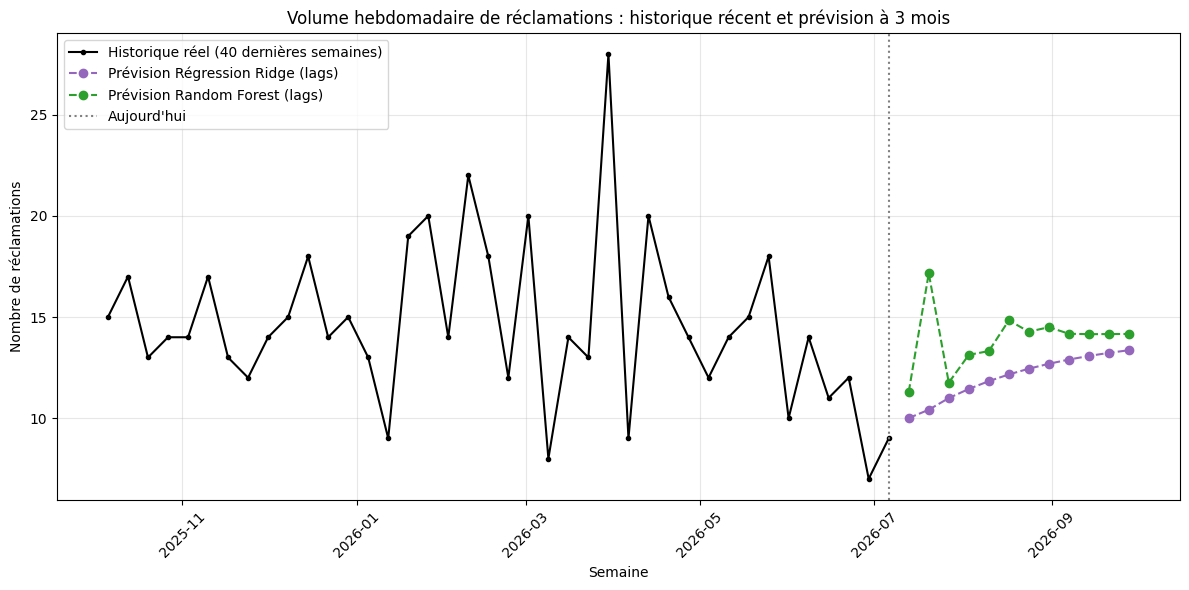

In [24]:

# 7. Graphique
# ---------------------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.plot(serie.index[-40:], serie.values[-40:], label="Historique réel (40 dernières semaines)",
          color="black", marker="o", markersize=3)
plt.plot(ridge_future.index, ridge_future.values, label="Prévision Régression Ridge (lags)",
          linestyle="--", marker="o", color="tab:purple")
plt.plot(rf_future.index, rf_future.values, label="Prévision Random Forest (lags)",
          linestyle="--", marker="o", color="tab:green")
plt.axvline(serie.index[-1], color="gray", linestyle=":", label="Aujourd'hui")
plt.title("Volume hebdomadaire de réclamations : historique récent et prévision à 3 mois")
plt.xlabel("Semaine")
plt.ylabel("Nombre de réclamations")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()